In [3]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# **0. CONTEXTO Y CARGA DATOS**

**Objetivo**:

Clasificar casas según su la región en la que se encuentren y del ingreso medio. Para ello, utilizaremos el famoso conjunto de datos California Housing. Se construyó utilizando los datos del censo de California de 1990. Contiene una fila por grupo de bloques censales. Un grupo de bloques es la unidad geográfica más pequeña para la que se publican datos del censo de USA.

In [4]:
df_completo=pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv")
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
#Seleccionamos las variables de estudio
df=df_completo[["Latitude", "Longitude", "MedInc"]]
df.head(5)

,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462


# **1. CRIBADO MANUAL**

## 1.1. Verificar valores

### 1.1.1. Unicos

In [6]:
# Valores unicos por cada columna
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


### 1.1.2. Eliminación de filas y columnas duplicadas

In [7]:
fil_dup=df.duplicated(keep="last") # keep=last: Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

Hay 5 filas duplicadas


In [8]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
col_dup=df.T.duplicated(keep="last")
print("No hay variables exactamente iguales" if col_dup.sum()==0 else f"Hay {fil_dup.sum()} variables exactamente iguales")

No hay variables exactamente iguales


## 1.2. Verificar missing values

In [9]:
df.select_dtypes(["int64", "float64"]).describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
Longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
MedInc,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001


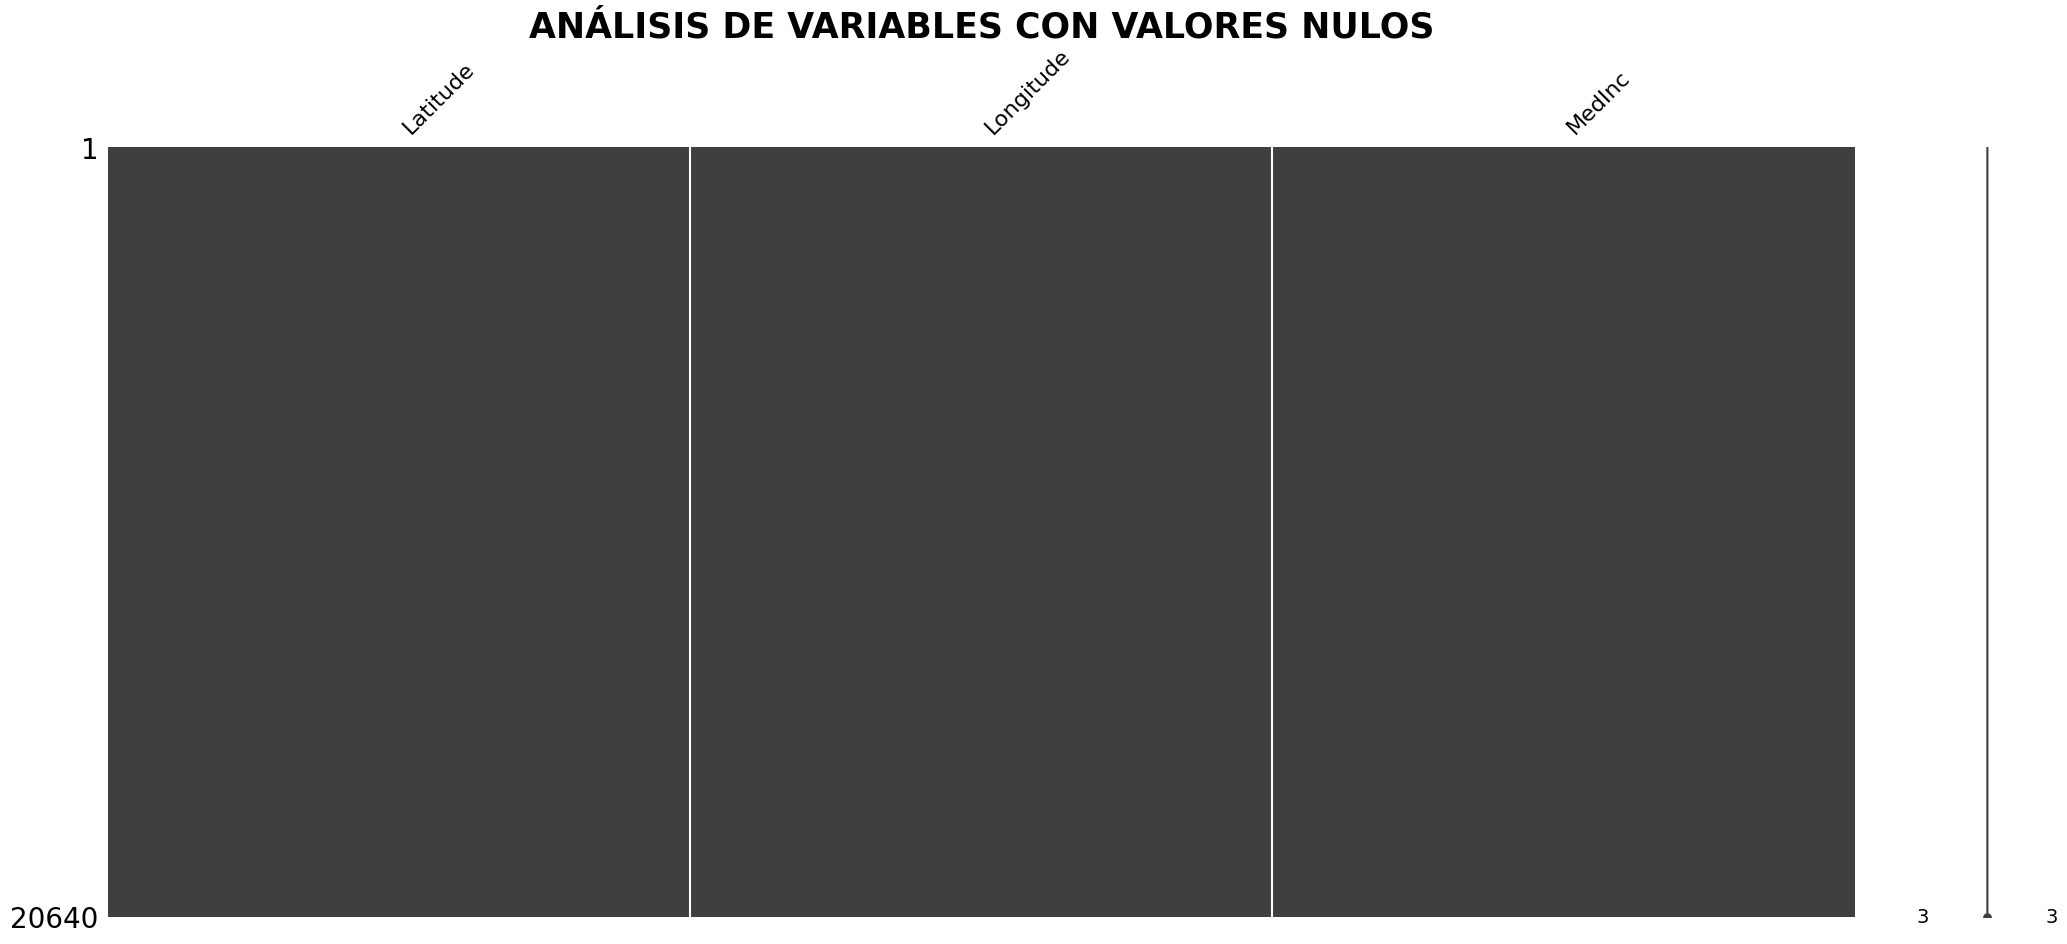

In [11]:
#Gráficamente
msno.matrix(df)
plt.title("ANÁLISIS DE VARIABLES CON VALORES NULOS", fontweight="bold", size=25)
plt.show()

## 1.3. División Train-Test

In [12]:
X_train, X_test=train_test_split(df, test_size=0.2, random_state=42)

## 1.4. Escalado de datos

In [13]:
#Instaciamos el escalador
scal=MinMaxScaler()
##Ajustamos y transformamos para train
train_sc=scal.fit_transform(X_train) #no es necesario escalar una variable con una escala cercana a 1 (0/1)
##Solo transformamos para test (independia base datos)
test_sc=scal.transform(X_test)

#Pasamos a df
##Train
X_train_sc=pd.DataFrame(train_sc, columns=X_train.columns, index=X_train.index)
##Test
X_test_sc=pd.DataFrame(test_sc, columns=X_test.columns, index=X_test.index)

In [14]:
X_train_sc.describe()

,Latitude,Longitude,MedInc
count,16512.000000,16512.000000,16512.000000
mean,0.329058,0.474871,0.233159
std,0.227305,0.199766,0.131329
min,0.000000,0.000000,0.000000
25%,0.146809,0.252988,0.142536
50%,0.181915,0.581673,0.210059
75%,0.550000,0.631474,0.294705
max,1.000000,1.000000,1.000000


# **2. MODELADO**